# Tarea 3 — Exploración y análisis de datos

**Rol:** Análisis de datos · **Hecho por:** Juliana Valbuena

**Pregunta de negocio:** ¿Qué proporción del valor total contratado por el ICBF se concentra
en un número reducido de proveedores/operadores, ha aumentado esta concentración en el
tiempo?

**Insumo:** este cuaderno parte de `icbf_clean.csv`

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("icbf_clean.csv")
#Se confirma que se subió bien el archivo revisando la dimension del dataframe
print(df.shape)
#Se imprimen las 5 columnas útiles para la pregunta de negocio
df[["referencia_del_contrato", "proveedor_adjudicado", "documento_proveedor", "saldo_cdp", "anio_firma"]].head()

C:\Users\jvalb\AppData\Local\Temp\ipykernel_11320\3495677429.py:5: DtypeWarning: Columns (0: recursos_de_credito) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("icbf_clean.csv")


(130122, 88)


,referencia_del_contrato,proveedor_adjudicado,documento_proveedor,saldo_cdp,anio_firma
0,CO1.PCCNTR.3474431,NaN,NaN,31401267.0,NaN
1,52002732025,HOGAR INFANTIL NIÑA MARIA,891200304,0.0,2025.0
2,CO1.PCCNTR.8675614,INDULTEC SOLUCIONES INTEGRALES SAS,901520694,0.0,NaN
3,19001732024,NaN,NaN,NaN,NaN
4,50001672025,CORPORACION COMUNIDAD DE VIDA,900365433,0.0,2025.0


## 0. Revisión rápida del contenido de las columnas de interés

Se revisan las estadísticas descriptivas de todas las columnas de interés para verificar que no se incorporen outliers al análisis y este sea confiable.

In [34]:
d = df.dropna(subset=["proveedor_adjudicado", "documento_proveedor", "saldo_cdp"]).copy()
#Se omiten los valores negativos de contratos (valores sin sentido)
d = d[d["saldo_cdp"] > 0]
print(d["saldo_cdp"].describe())
print(d["anio_firma"].describe())

#Se revisa el valor del percentil 99.99 vs valor máximo para confirmar la presencia de un outlier
p9999 = d["saldo_cdp"].quantile(0.9999)
valor_maximo = d["saldo_cdp"].max()
print(f"Percentil 99.99: ${p9999:,.0f} COP")
print(f"Valor máximo del dataset: ${valor_maximo:,.0f} COP")
print(f"El valor máximo es {valor_maximo / p9999:.1f} veces el percentil 99.99")

count    7.002400e+04
mean     1.281410e+09
std      1.015362e+10
min      7.440000e+02
25%      2.318716e+07
50%      4.726633e+07
75%      6.227208e+08
max      2.019011e+12
Name: saldo_cdp, dtype: float64
count    68952.000000
mean      2022.759064
std          1.866886
min       2017.000000
25%       2021.000000
50%       2023.000000
75%       2024.000000
max       2026.000000
Name: anio_firma, dtype: float64
Percentil 99.99: $171,782,198,918 COP
Valor máximo del dataset: $2,019,011,000,028 COP
El valor máximo es 11.8 veces el percentil 99.99


**Hallazgo:** el rango de `anio_firma` (2017-2026) es coherente, sin valores fuera de lo esperado.
Sin embargo, `saldo_cdp` muestra una señal de alerta, su valor máximo ($2,02 billones COP) es
**11,8 veces** el percentil 99,99 del resto de la muestra. Esto sugiere un posible
outlier que debe investigarse antes de continuar con el análisis de concentración, para no
distorsionar los resultados.

## 1. Eliminación de outlier

In [35]:
# Se identifica la fila del outlier detectado
fila_outlier = d.loc[d["saldo_cdp"].idxmax()]
print(fila_outlier[["referencia_del_contrato", "proveedor_adjudicado", "documento_proveedor", "saldo_cdp"]])

# Se guarda el documento del proveedor outlier para revisar cuantos contratos tiene
doc_outlier = fila_outlier["documento_proveedor"]
print(f"Contratos totales de este proveedor: {(d['documento_proveedor'] == doc_outlier).sum()}")

# Se identifica y excluye ese contrato especifico
outlier_mask = d["referencia_del_contrato"] == fila_outlier["referencia_del_contrato"]
print(f"Outlier excluido: {outlier_mask.sum()} contrato, valor: ${d.loc[outlier_mask, 'saldo_cdp'].sum():,.0f} COP")
d = d[~outlier_mask]

referencia_del_contrato                     01016142023
proveedor_adjudicado       Junior Humberto Montes Banda
documento_proveedor                          1032443197
saldo_cdp                               2019011000028.0
Name: 24240, dtype: object
Contratos totales de este proveedor: 2
Outlier excluido: 1 contrato, valor: $2,019,011,000,028 COP


El outlier tiene los siguientes datos: referencia `01016142023`, persona
natural con `saldo_cdp` de 2,02 billones COP (en total tiene 2 contratos en toda la base de datos), consistente con un error de
captura en la fuente y no con un valor real de contratación.

## 2. ¿Qué tan concentrada está la contratación del ICBF?

Se agrega por `documento_proveedor` (es más confiable que el nombre en texto, pues, puede tener variaciones de escritura).

In [36]:
# Se agrupan los contratos por proveedor
g = d.groupby("documento_proveedor").agg(
    proveedor=("proveedor_adjudicado", "first"),          # nombre a mostrar (el primero)
    n_contratos=("referencia_del_contrato", "nunique"),    # cuantos contratos distintos tiene
    valor_total=("saldo_cdp", "sum"),                      # suma del valor de todos sus contratos
).reset_index().sort_values("valor_total", ascending=False)  # de mayor a menor valor total

# Totales generales, para las participaciones de cada proveedor
n_proveedores = len(g)
valor_total_global = g["valor_total"].sum()
n_contratos_total = g["n_contratos"].sum()

# Que porcentaje del valor total y de los contratos totales le corresponde a cada proveedor
g["participacion_valor (%)"] = g["valor_total"] / valor_total_global * 100
g["participacion_contratos (%)"] = g["n_contratos"] / n_contratos_total * 100

# Resumen
print(f"Proveedores distintos: {n_proveedores:,}")
print(f"Valor total analizado (saldo CDP): ${valor_total_global:,.0f} COP")
print(f"Contratos analizados: {n_contratos_total:,}")
print()
print("Top 10 proveedores por valor contratado:")
g[["proveedor", "n_contratos", "valor_total", "participacion_valor (%)"]].head(10)

Proveedores distintos: 24,443
Valor total analizado (saldo CDP): $87,710,467,580,728 COP
Contratos analizados: 70,023

Top 10 proveedores por valor contratado:


,proveedor,n_contratos,valor_total,participacion_valor (%)
22287,FUNDACIÓN SERRANIA COLOMBIA,38,1.027249e+12,1.171182
21709,INSTITUTO PSICEDUCATIVO DE COLOMBIA - IPSICOL,101,6.899974e+11,0.786676
3648,Maria Camila Ochoa Echeverri,7,5.394375e+11,0.615021
20619,PARROQUIA SAN FRANCISCO DE ASIS,12,4.729235e+11,0.539187
22254,FUNDACIÓN CHOCÓ SOCIAL,29,4.717146e+11,0.537809
19390,FUNDACIÓN LICEO COMERCIAL CIUDAD DE EL BORDO,23,4.532827e+11,0.516794
22265,FUNJOTRABIUN,9,4.282333e+11,0.488235
21988,COOMACOVALLE,24,4.137760e+11,0.471752
18806,asociación de usuarios del programa hogares de...,5,4.136872e+11,0.471651
21920,FUNDACION CASA HOGAR NUESTRO SUEÑOS BARRIO REPOSO,15,3.953985e+11,0.450800


In [37]:
print("Razones de concentración sobre el valor contratado:")
# Se calcula para distintos tamaños de grupo,
# que % del valor total contratado concentran esos proveedores mas grandes
for k in [5, 10, 20, 50]:
    cr = g.head(k)["participacion_valor (%)"].sum()
    print(f"  CR{k:<3d}: {cr:5.1f}% del valor está en los {k} mayores proveedores "
          f"({k/n_proveedores*100:.2f}% de los {n_proveedores:,} proveedores)")

Razones de concentración sobre el valor contratado:
  CR5  :   3.6% del valor está en los 5 mayores proveedores (0.02% de los 24,443 proveedores)
  CR10 :   6.0% del valor está en los 10 mayores proveedores (0.04% de los 24,443 proveedores)
  CR20 :  10.2% del valor está en los 20 mayores proveedores (0.08% de los 24,443 proveedores)
  CR50 :  17.5% del valor está en los 50 mayores proveedores (0.20% de los 24,443 proveedores)


## 3. ¿Ha aumentado la concentración en el tiempo?

Se responde la segunda mitad de la pregunta de negocio calculando, año por año, qué porcentaje
del valor de ese año se llevaron los 10 proveedores más grandes **de ese mismo año** (no del
período completo).

In [38]:
resultados_anio = []
for anio in range(2017, 2027):
    d_anio = d[d["anio_firma"] == anio]
    g_anio = d_anio.groupby("documento_proveedor").agg(
        valor_total=("saldo_cdp", "sum"),
    ).reset_index().sort_values("valor_total", ascending=False)

    valor_total_anio = g_anio["valor_total"].sum()
    n_proveedores_anio = len(g_anio)
    cr10_anio = g_anio.head(10)["valor_total"].sum() / valor_total_anio * 100

    resultados_anio.append({
        "anio": anio,
        "n_proveedores": n_proveedores_anio,
        "valor_total": valor_total_anio,
        "CR10 (%)": cr10_anio,
    })

evolucion = pd.DataFrame(resultados_anio)
evolucion

,anio,n_proveedores,valor_total,CR10 (%)
0,2017,39,1.169010e+09,61.677129
1,2018,200,2.592764e+10,89.386419
2,2019,257,1.190822e+11,71.611049
3,2020,7531,7.468110e+12,26.313248
4,2021,6585,2.392169e+13,12.754944
5,2022,7724,1.884385e+13,8.851433
6,2023,7956,2.045800e+13,9.999275
7,2024,10775,4.936521e+12,18.412824
8,2025,6403,2.469147e+12,23.083768
9,2026,4212,7.341785e+11,19.846978


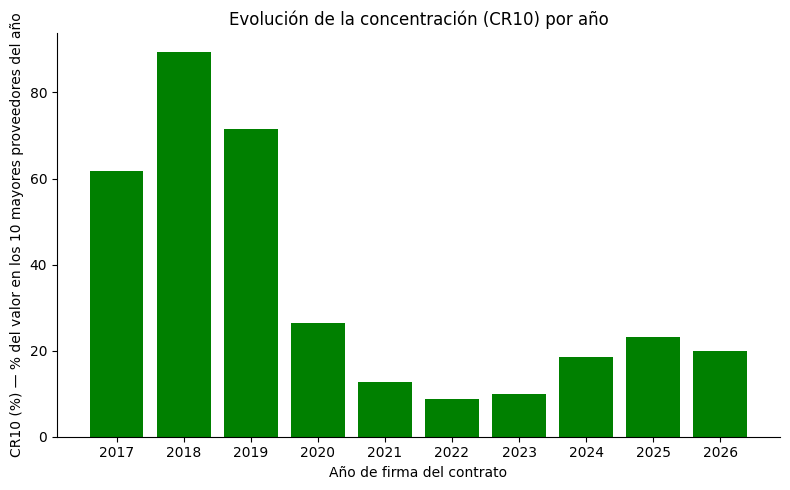

In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(evolucion["anio"].astype(str), evolucion["CR10 (%)"], color="green")
ax.set_xlabel("Año de firma del contrato")
ax.set_ylabel("CR10 (%) — % del valor en los 10 mayores proveedores del año")
ax.set_title("Evolución de la concentración (CR10) por año")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

**Hallazgo:** el CR10 no muestra una tendencia sostenida al alza — varía de un año a otro
sin un patrón claro de aumento. No hay evidencia de que la concentración esté creciendo con el
tiempo.

### 3.1 ¿Quiénes lideran cada año?

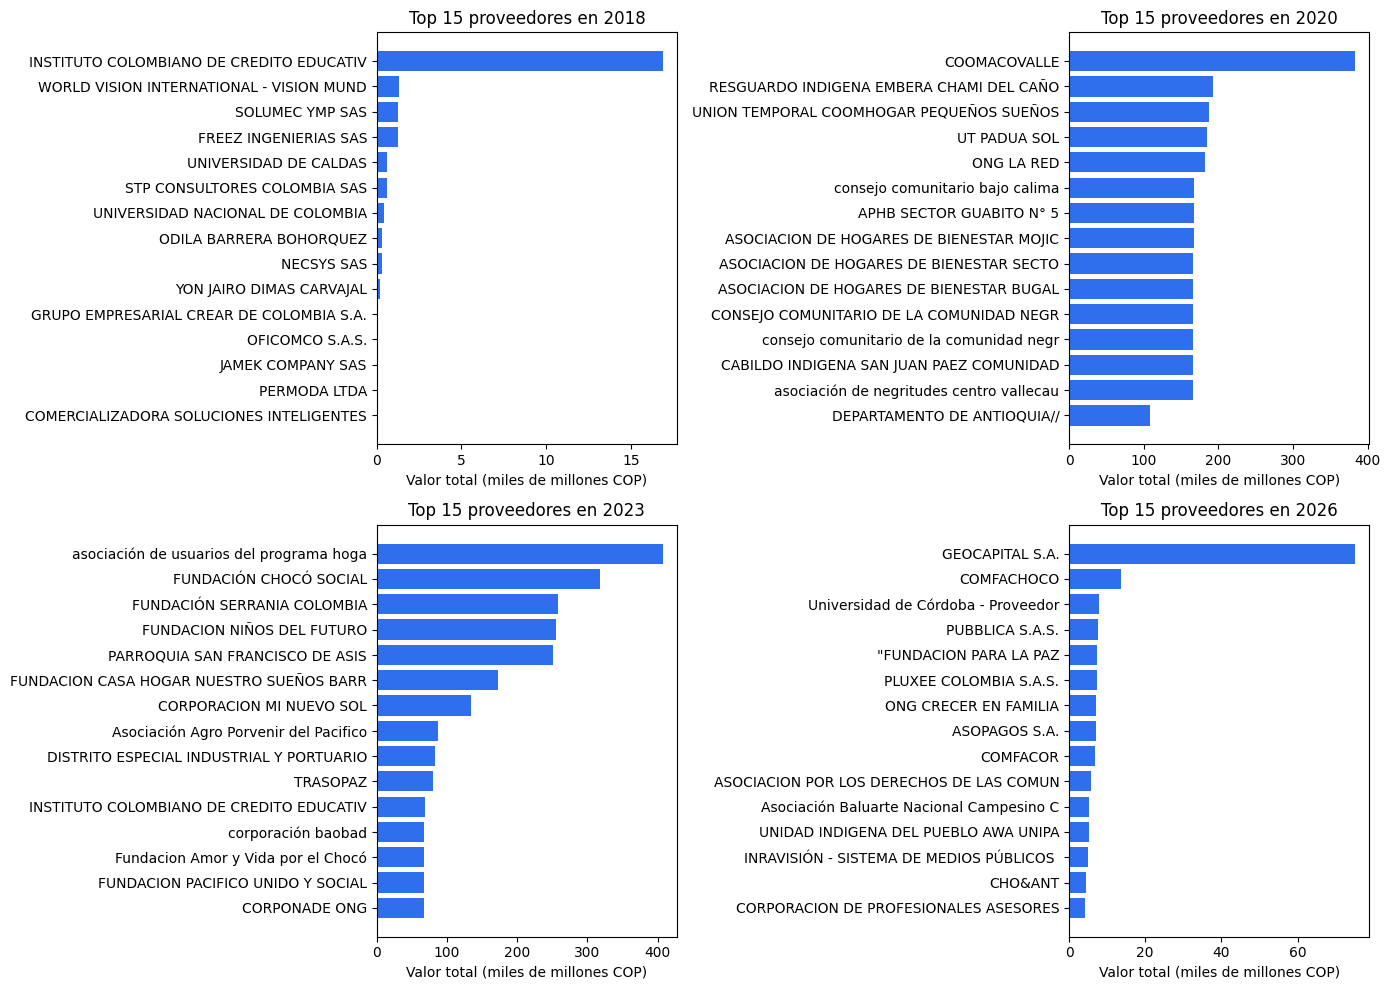

In [40]:
anios_interes = [2018, 2020, 2023, 2026]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for anio, ax in zip(anios_interes, axes.flat):
    # Se filtran solo los contratos firmados en ese año
    d_anio = d[d["anio_firma"] == anio]

    # Se agrupa por proveedor, pero solo con los datos de ese año
    g_anio = d_anio.groupby("documento_proveedor").agg(
        proveedor=("proveedor_adjudicado", "first"),
        valor_total=("saldo_cdp", "sum"),
    ).reset_index().sort_values("valor_total", ascending=False)

    top15_anio = g_anio.head(15).iloc[::-1]

    ax.barh(top15_anio["proveedor"].str.slice(0, 40), top15_anio["valor_total"] / 1e9, color="#2f6fed")
    ax.set_xlabel("Valor total (miles de millones COP)")
    ax.set_title(f"Top 15 proveedores en {anio}")

fig.tight_layout()
plt.show()

In [41]:
# Se junta en una tabla el top 15 de cada año
tablas = []
for anio in range(2017, 2027):
    d_anio = d[d["anio_firma"] == anio]
    g_anio = d_anio.groupby("documento_proveedor").agg(
        proveedor=("proveedor_adjudicado", "first"),
        valor_total=("saldo_cdp", "sum"),
    ).reset_index().sort_values("valor_total", ascending=False).head(15)
    tablas.append(g_anio)

top15_todos = pd.concat(tablas)

# Se cuenta cuantas veces aparece cada proveedor sumando los top-15 de todos los años
conteo = top15_todos["documento_proveedor"].value_counts()
repetidos = conteo[conteo > 1]

print(f"Proveedores que se repiten en mas de un año: {len(repetidos)}")
repetidos

Proveedores que se repiten en mas de un año: 19


documento_proveedor
900252699    3
805020621    3
899999035    2
900319291    2
900002583    2
890900286    2
890905211    2
830506297    2
900005961    2
818000937    2
900326335    2
900696442    2
830085547    2
860005068    2
890102018    2
890983904    2
814006325    2
805000867    2
891600091    2
Name: count, dtype: int64

In [42]:
#Se buscan los proveedores que se encontraron repetidos en los años registrados
for doc, veces in repetidos.items():
    nombre = d.loc[d["documento_proveedor"] == doc, "proveedor_adjudicado"].iloc[0]
    print(f"{doc}: {nombre} (se repite {veces} veces)")

900252699: FUNDACIÓN SERRANIA COLOMBIA (se repite 3 veces)
805020621: ONG CRECER EN FAMILIA (se repite 3 veces)
899999035: INSTITUTO COLOMBIANO DE CREDITO EDUCATIVO Y ESTUDIO TÉCNICOS EN EL EXTERIOR MARIANO OSPINA PEREZ. (se repite 2 veces)
900319291: ASOPAGOS S.A. (se repite 2 veces)
900002583: INRAVISIÓN - SISTEMA DE MEDIOS PÚBLICOS DEL ESTADO COLOMBIANO S.A.S (se repite 2 veces)
890900286: DEPARTAMENTO DE ANTIOQUIA// (se repite 2 veces)
890905211: DISTRITO ESPECIAL DE CIENCIA TECNOLOGIA E INNOVACION DE MEDELLIN (se repite 2 veces)
830506297: FUNDACION PÈRTENENCIA (se repite 2 veces)
900005961: FUNDACION CASA HOGAR NUESTRO SUEÑOS BARRIO REPOSO (se repite 2 veces)
818000937: PARROQUIA SAN FRANCISCO DE ASIS (se repite 2 veces)
900326335: Fundacion Amor y Vida por el Chocó (se repite 2 veces)
900696442: Asociación Agro Porvenir del Pacifico (se repite 2 veces)
830085547: CORPORACIÓN AMOR POR COLOMBIA AXC (se repite 2 veces)
860005068: CONGREGACION DE RELIGIOSOS TERCIARIOS CAPUCHINOS DE 

In [43]:
anios_todos = sorted(int(a) for a in d["anio_firma"].dropna().unique())

top1_por_anio = []
for anio in anios_todos:
    d_anio = d[d["anio_firma"] == anio]
    g_anio = d_anio.groupby("documento_proveedor").agg(
        proveedor=("proveedor_adjudicado", "first"),
        valor_total=("saldo_cdp", "sum"),
    ).reset_index().sort_values("valor_total", ascending=False)
    fila = g_anio.iloc[0]
    top1_por_anio.append({"anio": anio, "proveedor": fila["proveedor"], "valor_total": fila["valor_total"]})

tabla_top1 = pd.DataFrame(top1_por_anio)
tabla_top1["valor_total (miles de mill. COP)"] = (tabla_top1["valor_total"] / 1e9).round(2)
tabla_top1

,anio,proveedor,valor_total,valor_total (miles de mill. COP)
0,2017,SODECOL SAS,3.530899e+08,0.35
1,2018,INSTITUTO COLOMBIANO DE CREDITO EDUCATIVO Y ES...,1.687500e+10,16.88
2,2019,U.T. FAMILIA MIC 2019,2.447698e+10,24.48
3,2020,COOMACOVALLE,3.828470e+11,382.85
4,2021,FUNDACIÓN SERRANIA COLOMBIA,5.700119e+11,570.01
5,2022,INGREDION COLOMBIA SA,3.511212e+11,351.12
6,2023,asociación de usuarios del programa hogares de...,4.071501e+11,407.15
7,2024,INSTITUTO PSICEDUCATIVO DE COLOMBIA - IPSICOL,6.562179e+11,656.22
8,2025,correagro,3.747623e+11,374.76
9,2026,GEOCAPITAL S.A.,7.505540e+10,75.06


**Conclusión de la sección:** aunque el CR10 no crece con el tiempo, el liderazgo **sí
rota** casi por completo de un año a otro (solo 19 de los ~60 proveedores que aparecieron en
algún top-15 se repiten en más de un año). Esto refuerza la conclusión de que no hay
dependencia sostenida de un mismo grupo de proveedores.

## 4. Distribución del valor por proveedor

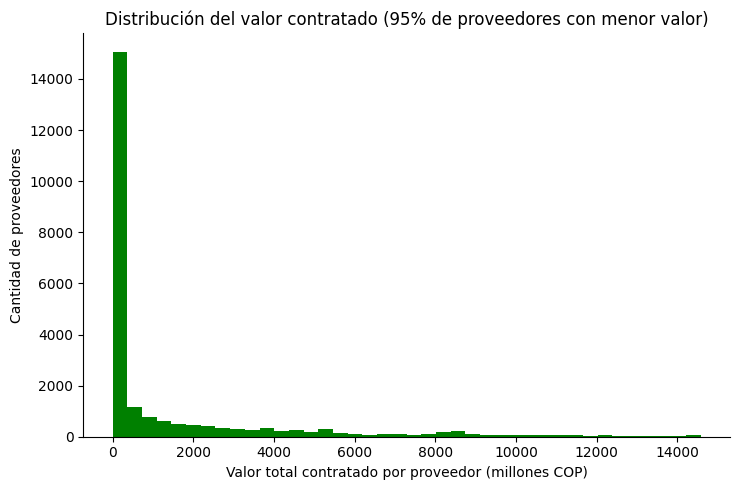

El 5% de proveedores con mayor valor (no incluido en este grafico) concentra el 62.9% del valor total


In [51]:
p95 = g["valor_total"].quantile(0.95)
g_tipico = g[g["valor_total"] <= p95]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(g_tipico["valor_total"] / 1e6, bins=40, color="green")
ax.set_xlabel("Valor total contratado por proveedor (millones COP)")
ax.set_ylabel("Cantidad de proveedores")
ax.set_title("Distribución del valor contratado (95% de proveedores con menor valor)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

pct_top5 = g.loc[g["valor_total"] > p95, "valor_total"].sum() / g["valor_total"].sum() * 100
print(f"El 5% de proveedores con mayor valor (no incluido en este grafico) concentra el {pct_top5:.1f}% del valor total")

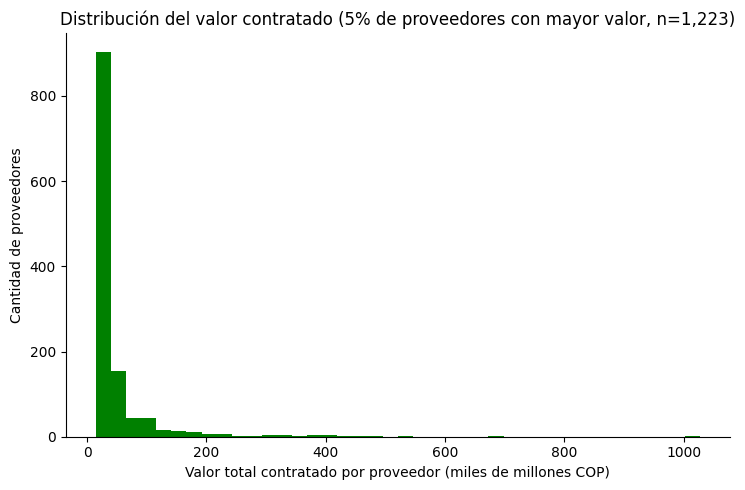

In [52]:
g_top5 = g[g["valor_total"] > p95]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(g_top5["valor_total"] / 1e9, bins=40, color="green")
ax.set_xlabel("Valor total contratado por proveedor (miles de millones COP)")
ax.set_ylabel("Cantidad de proveedores")
ax.set_title(f"Distribución del valor contratado (5% de proveedores con mayor valor, n={len(g_top5):,})")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

**Hallazgo:** el 95% de los proveedores (los más numerosos) se concentra en valores bajos,
la mayoría por debajo de $300 millones COP (primer histograma). El 5% restante, aunque son
muy pocos proveedores, concentra el 62,9% del valor total contratado (segundo histograma) — una
confirmación adicional, en términos simples, de la desigualdad que ya viste en el CR.

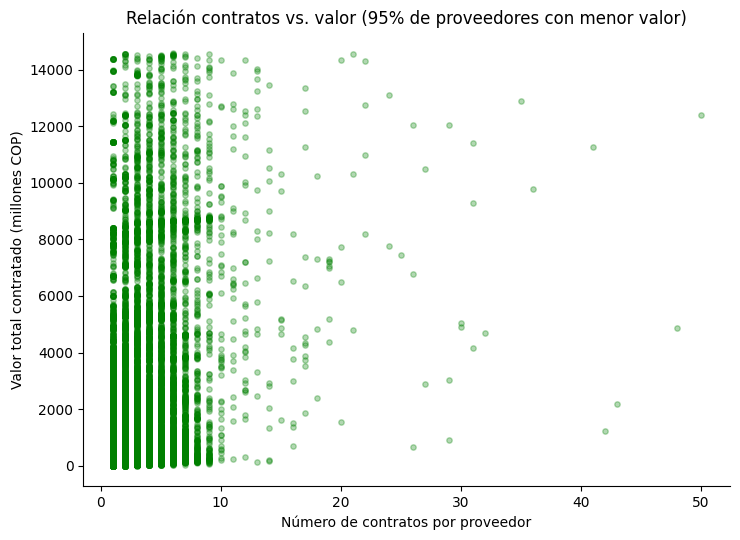

In [53]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(g_tipico["n_contratos"], g_tipico["valor_total"] / 1e6, alpha=0.3, s=15, color="green")
ax.set_xlabel("Número de contratos por proveedor")
ax.set_ylabel("Valor total contratado (millones COP)")
ax.set_title("Relación contratos vs. valor (95% de proveedores con menor valor)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 5. ¿Los proveedores con más contratos son los que más valor acumulan?

Se crea una variable nueva, el valor promedio por contrato de cada proveedor, para entender
si el valor total de un proveedor viene de tener muchos contratos o de tener contratos más
grandes.

In [47]:
# Nueva caracteristica: valor promedio por contrato de cada proveedor
g["valor_promedio_contrato"] = g["valor_total"] / g["n_contratos"]
g[["proveedor", "n_contratos", "valor_total", "valor_promedio_contrato"]].sort_values("valor_promedio_contrato", ascending=False).head(10)

,proveedor,n_contratos,valor_total,valor_promedio_contrato
21539,INGREDION COLOMBIA SA,1,3.511212e+11,3.511212e+11
22892,Fundación para el Desarrollo Integral de Grupo...,1,1.086064e+11,1.086064e+11
21674,DEPARTAMENTO DE ANTIOQUIA//,3,3.135849e+11,1.045283e+11
20092,correagro,4,3.949141e+11,9.872851e+10
21076,consejo comunitario bajo calima,2,1.695135e+11,8.475676e+10
22095,ASOCIACION DE HOGARES DE BIENESTAR SECTOR MOJI...,2,1.664935e+11,8.324676e+10
21071,consejo comunitario de la comunidad negra de l...,2,1.660658e+11,8.303290e+10
18806,asociación de usuarios del programa hogares de...,5,4.136872e+11,8.273744e+10
3648,Maria Camila Ochoa Echeverri,7,5.394375e+11,7.706251e+10
23695,UNION TEMPORAL CUIDAR Y PROTEGER A LA PRIMERA ...,1,7.701192e+10,7.701192e+10


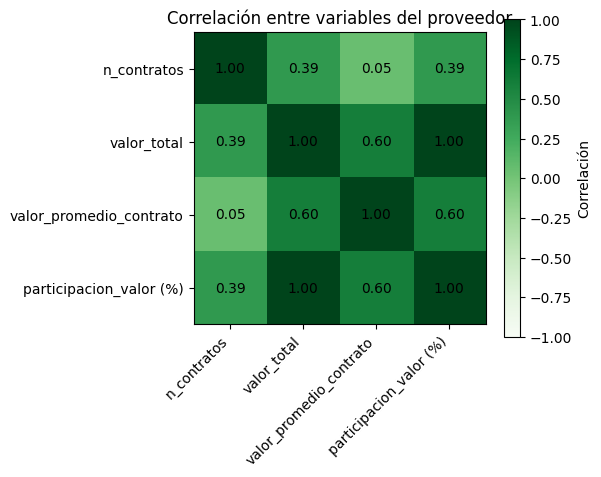

In [48]:
# Mapa de calor de correlacion entre las variables numericas relevantes
variables = g[["n_contratos", "valor_total", "valor_promedio_contrato", "participacion_valor (%)"]]
correlaciones = variables.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(correlaciones, cmap="Greens", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlaciones.columns)))
ax.set_yticks(range(len(correlaciones.columns)))
ax.set_xticklabels(correlaciones.columns, rotation=45, ha="right")
ax.set_yticklabels(correlaciones.columns)

for i in range(len(correlaciones)):
    for j in range(len(correlaciones)):
        ax.text(j, i, f"{correlaciones.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, label="Correlación")
ax.set_title("Correlación entre variables del proveedor")
fig.tight_layout()
plt.show()

In [49]:
from scipy.stats import spearmanr

r, p_valor = spearmanr(g["n_contratos"], g["valor_total"])
print(f"Correlación de Spearman entre n_contratos y valor_total: {r:.3f}")
print(f"P-valor: {p_valor:.2e}")

Correlación de Spearman entre n_contratos y valor_total: 0.664
P-valor: 0.00e+00


**Hallazgo:** la correlación de Spearman entre `n_contratos` y `valor_total` es de
**0,66** (p-valor prácticamente cero, es decir, estadísticamente significativa), hay una
relación positiva moderada-fuerte: los proveedores con más contratos sí tienden a acumular más
valor. Sin embargo, no es una relación perfecta (no es 1.0). El mapa de calor también muestra
que `valor_promedio_contrato` casi no se correlaciona con `n_contratos`, es decir, tener muchos
contratos no implica que cada uno sea grande, hay proveedores con pocos contratos pero de alto
valor individual, y viceversa.

## 6. ¿Cómo se comporta el valor de los contratos individuales a través de los años?

Complementa la sección 3: en vez de ver el total agregado por año, se observa cómo varía el
valor de cada contrato individual (`saldo_cdp`) año a año.

C:\Users\jvalb\AppData\Local\Temp\ipykernel_11320\4154190597.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(datos_por_anio, labels=[str(int(a)) for a in anios_orden], showfliers=False)


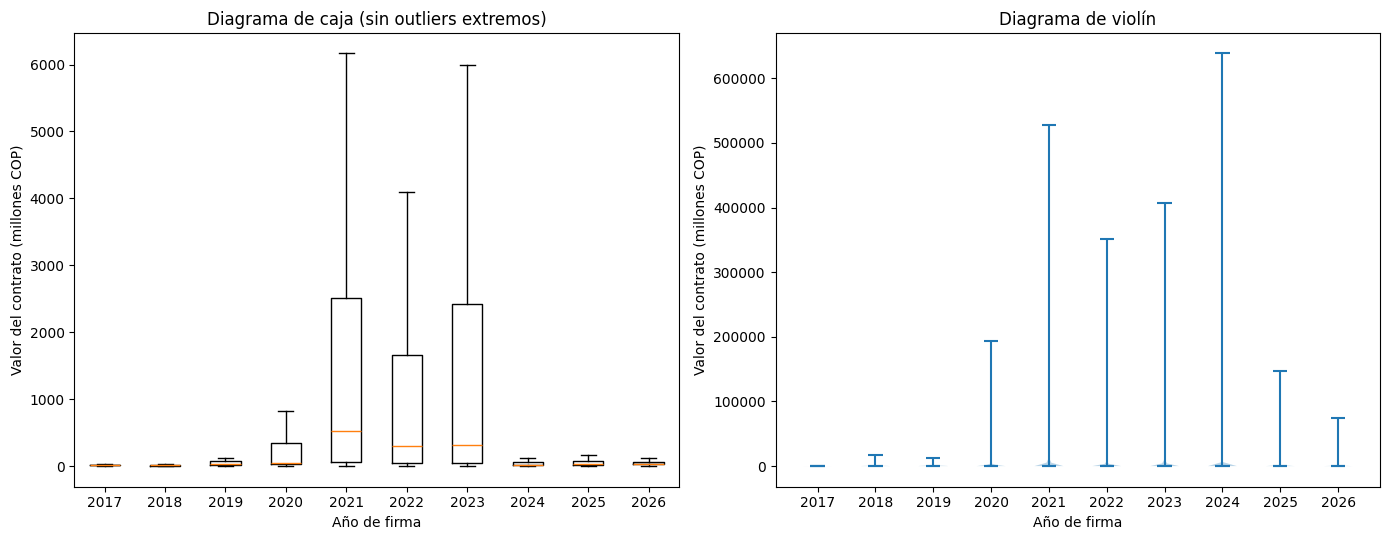

In [50]:
d_valido = d[d["anio_firma"].between(2017, 2026)].copy()
anios_orden = sorted(d_valido["anio_firma"].dropna().unique())
datos_por_anio = [d_valido.loc[d_valido["anio_firma"] == a, "saldo_cdp"] / 1e6 for a in anios_orden]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].boxplot(datos_por_anio, labels=[str(int(a)) for a in anios_orden], showfliers=False)
axes[0].set_xlabel("Año de firma")
axes[0].set_ylabel("Valor del contrato (millones COP)")
axes[0].set_title("Diagrama de caja (sin outliers extremos)")

axes[1].violinplot(datos_por_anio, showmedians=True)
axes[1].set_xticks(range(1, len(anios_orden) + 1))
axes[1].set_xticklabels([str(int(a)) for a in anios_orden])
axes[1].set_xlabel("Año de firma")
axes[1].set_ylabel("Valor del contrato (millones COP)")
axes[1].set_title("Diagrama de violín")

fig.tight_layout()
plt.show()

**Hallazgo:** la mediana y la dispersión del valor por contrato se mantienen relativamente
estables a lo largo de los años (sin un aumento sostenido), lo cual es consistente con el CR10
de la sección 3, la forma en que se reparte el valor entre proveedores no cambia drásticamente
año a año.